# Highland Square Conjoint — Notebook 2 (FIXED): Analyze & Visualize

## Fixes applied vs. previous version

1. **Dropped synthetic D rows** — no outside option was chosen in the raw data, so we don't represent D in the regression at all. This removes the duplicate CommuteToWork label and the meaningless ASC_D coefficient.
2. **Matched CommuteToWork labels** to the actual data labels (`Quick (under 15 min by car)` format).
3. **Added position fixed effects (ASC_B, ASC_C)** to absorb the LLM's letter-B preference. Other coefficients are now estimated *net of position bias*.
4. **Market-share simulator uses `include_outside=False`** since we have no outside-option data — shares are *conditional* on choosing to lease.

## Pipeline
1. Load and parse raw responses
2. Reshape to long format (A, B, C only — no synthetic D)
3. Fit multinomial logit with position fixed effects
4. Compute marginal WTP
5. Visualize
6. Per-persona models
7. Market-share simulator (conditional share)
8. Save outputs for Notebook 3 (simulator)

**Input:** `data/raw_responses.csv`  
**Outputs (under `data/`):** `wtp_table.csv` (WTP), `persona_coefs.csv` + `persona_coefs.json`, `pooled_coefs.csv`, `attributes.csv` + `attributes.json`, `persona_wtp.csv` (heatmap table); plus plots. Ready for Notebook 3.

## 0. Setup

In [1]:
# !pip install xlogit --quiet

In [2]:
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xlogit import MultinomialLogit

warnings.filterwarnings('ignore')
DATA_DIR = Path("data")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Setup complete.")

Setup complete.


## 1. ATTRIBUTES dict — labels MUST match what's in `raw_responses.csv`

Critical: this dict is used to compute numeric values (Size_num, Price_num) and to derive the categorical baseline level. The labels here must exactly match what's stored in `raw_responses.csv`.

**CommuteToWork labels here use the `by car` format that's actually in the data — NOT the `daily destination` format.**

In [3]:
ATTRIBUTES = {
    "Size": {
        "750 SF (compact 1BR)": 750,
        "1,000 SF (large 1BR / compact 2BR)": 1000,
        "1,250 SF (standard 2BR)": 1250,
    },
    "Price": {
        "$1,650/mo": 1650,
        "$1,950/mo": 1950,
        "$2,250/mo": 2250,
        "$2,550/mo": 2550,
    },
    "MoveInSpecial": {
        "None": None,
        "1 month free (12-mo lease)": None,
        "2 months free (13-mo lease)": None,
    },
    "Location": {
        "North Druid Hills / Briarcliff": None,
        "Virginia-Highland / Morningside": None,
        "Decatur / Emory Village": None,
        "Buckhead / Lenox": None,
    },
    "CommuteToWork": {
        "Quick (under 15 min by car)": None,
        "Average (15-30 min by car)": None,
        "Long (over 30 min by car)": None,
    },
    "Walkability": {
        "Car-Required (drive for groceries, dining, errands from this building)": None,
        "Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)": None,
        "Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)": None,
    },
    "Finishes": {
        "Builder-grade (laminate counters, basic appliances, no smart features)": None,
        "Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)": None,
        "Premium (quartz waterfall island, smart thermostat, keyless entry, video doorbell)": None,
    },
    "Parking": {
        "Surface lot, unassigned parking, no gate": None,
        "Gated surface lot + reserved space option": None,
        "Dedicated garage with assigned space + EV charging": None,
    },
    "Security": {
        "Tier 1: Open access, no controlled entry": None,
        "Tier 2: Perimeter gate + controlled-access lobby + camera coverage": None,
        "Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout": None,
    },
    "Rooftop": {
        "No rooftop space": None,
        "Rooftop lounge with skyline views & outdoor seating": None,
    },
    "Coworking": {
        "No dedicated coworking space": None,
        "Resident co-working lounge with private call rooms & wifi": None,
    },
    "PetAmenities": {
        "No pet amenities": None,
        "Standard dog park only": None,
        "Dog park + pet spa with grooming station": None,
    },
    "PackageHandling": {
        "Standard mailroom (sign for packages during office hours)": None,
        "24/7 Amazon Hub lockers + refrigerated grocery locker": None,
    },
}

attr_names = list(ATTRIBUTES.keys())
CONTINUOUS_ATTRS = [a for a in attr_names if any(v is not None for v in ATTRIBUTES[a].values())]
CATEGORICAL_ATTRS = [a for a in attr_names if a not in CONTINUOUS_ATTRS]
print(f"Continuous: {CONTINUOUS_ATTRS}")
print(f"Categorical ({len(CATEGORICAL_ATTRS)}): {CATEGORICAL_ATTRS}")

Continuous: ['Size', 'Price']
Categorical (11): ['MoveInSpecial', 'Location', 'CommuteToWork', 'Walkability', 'Finishes', 'Parking', 'Security', 'Rooftop', 'Coworking', 'PetAmenities', 'PackageHandling']


## 2. Load & Parse Raw Responses

In [4]:
raw_df = pd.read_csv(DATA_DIR / "raw_responses.csv")
print(f"Total rows: {len(raw_df)}")
print(f"Errors: {raw_df['Error'].notna().sum() if 'Error' in raw_df.columns else 0}")

# Drop errors if column exists
if 'Error' in raw_df.columns:
    df = raw_df[raw_df['Error'].isna()].copy()
else:
    df = raw_df.copy()

# Parse choice letter A/B/C (no D expected)
def parse_choice(text):
    if pd.isna(text): return None
    m = re.search(r'\b([ABCD])\b', str(text)[:50])
    return m.group(1) if m else None

df['Choice'] = df['Response'].apply(parse_choice)
print(f"\nChoice distribution:")
print(df['Choice'].value_counts())

df = df[df['Choice'].notna()].copy()
print(f"\nUsable rows: {len(df)}")

Total rows: 7200
Errors: 0

Choice distribution:
Choice
B    3012
C    2263
A    1925
Name: count, dtype: int64

Usable rows: 7200


## 3. Reshape to Long Format (A, B, C only — NO synthetic D)

This is the key fix. We do not add a synthetic D row. Each observation becomes 3 rows (one per real alternative).

In [5]:
df['ObsID'] = df.apply(lambda r: f"{r['Persona']}_t{r['Task_ID']}_r{r['Rep']}", axis=1)
df['Profiles'] = df['Shuffled_Profiles'].apply(json.loads)

# Verify each task has 3 profiles
assert (df['Profiles'].apply(len) == 3).all(), "Some tasks don't have 3 profiles"

long_rows = []
for _, row in df.iterrows():
    chosen = row['Choice']
    if chosen == 'D':
        # If somehow a D response slipped in, skip it
        continue
    for j, profile in enumerate(row['Profiles']):
        alt_label = chr(ord('A') + j)
        rec = {
            'ObsID': row['ObsID'],
            'Persona': row['Persona'],
            'Alt': alt_label,
            'choice': 1 if chosen == alt_label else 0,
        }
        for attr in attr_names:
            rec[attr] = profile[attr]
        rec['Size_num'] = ATTRIBUTES['Size'][profile['Size']]
        rec['Price_num'] = ATTRIBUTES['Price'][profile['Price']]
        long_rows.append(rec)

long_df = pd.DataFrame(long_rows)
print(f"Long format rows: {len(long_df)} (expected: {len(df)*3} = {len(df)*3})")
print(f"Sum of choice: {long_df['choice'].sum()} (should equal {len(df)})")
long_df.head(6)

Long format rows: 21600 (expected: 21600 = 21600)
Sum of choice: 7200 (should equal 7200)


,ObsID,Persona,Alt,choice,Size,Price,MoveInSpecial,Location,CommuteToWork,Walkability,Finishes,Parking,Security,Rooftop,Coworking,PetAmenities,PackageHandling,Size_num,Price_num
0,emory_grad_t0_r0,emory_grad,A,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",2 months free (13-mo lease),Decatur / Emory Village,Average (15-30 min by car),Walkable Errands (groceries & a few restaurant...,"Mid-tier (granite/quartz counters, stainless a...",Dedicated garage with assigned space + EV char...,Tier 3: Tier 2 + 24/7 staff or virtual concier...,Rooftop lounge with skyline views & outdoor se...,No dedicated coworking space,Dog park + pet spa with grooming station,24/7 Amazon Hub lockers + refrigerated grocery...,1000,2550
1,emory_grad_t0_r0,emory_grad,B,1,"1,250 SF (standard 2BR)","$2,250/mo",None,Virginia-Highland / Morningside,Quick (under 15 min by car),"Car-Required (drive for groceries, dining, err...","Mid-tier (granite/quartz counters, stainless a...",Gated surface lot + reserved space option,"Tier 1: Open access, no controlled entry",No rooftop space,No dedicated coworking space,Standard dog park only,24/7 Amazon Hub lockers + refrigerated grocery...,1250,2250
2,emory_grad_t0_r0,emory_grad,C,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",1 month free (12-mo lease),Decatur / Emory Village,Long (over 30 min by car),"Walk Everywhere (daily errands, dining, transi...","Mid-tier (granite/quartz counters, stainless a...","Surface lot, unassigned parking, no gate",Tier 2: Perimeter gate + controlled-access lob...,Rooftop lounge with skyline views & outdoor se...,Resident co-working lounge with private call r...,No pet amenities,Standard mailroom (sign for packages during of...,1000,2550
3,emory_grad_t0_r1,emory_grad,A,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",1 month free (12-mo lease),Decatur / Emory Village,Long (over 30 min by car),"Walk Everywhere (daily errands, dining, transi...","Mid-tier (granite/quartz counters, stainless a...","Surface lot, unassigned parking, no gate",Tier 2: Perimeter gate + controlled-access lob...,Rooftop lounge with skyline views & outdoor se...,Resident co-working lounge with private call r...,No pet amenities,Standard mailroom (sign for packages during of...,1000,2550
4,emory_grad_t0_r1,emory_grad,B,0,"1,000 SF (large 1BR / compact 2BR)","$2,550/mo",2 months free (13-mo lease),Decatur / Emory Village,Average (15-30 min by car),Walkable Errands (groceries & a few restaurant...,"Mid-tier (granite/quartz counters, stainless a...",Dedicated garage with assigned space + EV char...,Tier 3: Tier 2 + 24/7 staff or virtual concier...,Rooftop lounge with skyline views & outdoor se...,No dedicated coworking space,Dog park + pet spa with grooming station,24/7 Amazon Hub lockers + refrigerated grocery...,1000,2550
5,emory_grad_t0_r1,emory_grad,C,1,"1,250 SF (standard 2BR)","$2,250/mo",None,Virginia-Highland / Morningside,Quick (under 15 min by car),"Car-Required (drive for groceries, dining, err...","Mid-tier (granite/quartz counters, stainless a...",Gated surface lot + reserved space option,"Tier 1: Open access, no controlled entry",No rooftop space,No dedicated coworking space,Standard dog park only,24/7 Amazon Hub lockers + refrigerated grocery...,1250,2250


In [6]:
# Add position fixed effects to absorb LLM B-bias
long_df['ASC_B'] = (long_df['Alt'] == 'B').astype(int)
long_df['ASC_C'] = (long_df['Alt'] == 'C').astype(int)
# Position A is the reference (omitted)

# Dummy-encode categorical attributes
long_df_encoded = pd.get_dummies(
    long_df,
    columns=CATEGORICAL_ATTRS,
    drop_first=True,
    prefix_sep='__',
)

# Convert booleans to ints (xlogit prefers numeric)
bool_cols = long_df_encoded.select_dtypes(include='bool').columns
long_df_encoded[bool_cols] = long_df_encoded[bool_cols].astype(int)

print(f"Encoded shape: {long_df_encoded.shape}")

# Inspect actual CommuteToWork values to verify no duplicate-label issue
commute_cols = [c for c in long_df_encoded.columns if c.startswith('CommuteToWork__')]
print(f"\nCommuteToWork dummy columns ({len(commute_cols)}):")
for c in commute_cols:
    print(f"  {c}")

Encoded shape: (21600, 30)

CommuteToWork dummy columns (2):
  CommuteToWork__Long (over 30 min by car)
  CommuteToWork__Quick (under 15 min by car)


## 4. Fit Multinomial Logit (pooled)

In [7]:
dummy_cols = [c for c in long_df_encoded.columns if '__' in c]
feature_cols = ['Size_num', 'Price_num', 'ASC_B', 'ASC_C'] + dummy_cols

print(f"Total features: {len(feature_cols)}")

X = long_df_encoded[feature_cols].values.astype(float)
y = long_df_encoded['choice'].values.astype(int)
ids = long_df_encoded['ObsID'].values
alts = long_df_encoded['Alt'].values

mnl = MultinomialLogit()
mnl.fit(X=X, y=y, varnames=feature_cols, ids=ids, alts=alts)
mnl.summary()

Total features: 24


Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 34
    Function evaluations: 35
Estimation time= 2.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
Size_num                0.0052308     0.0002632    19.8757624      1.26e-85 ***
Price_num              -0.0085678     0.0002537   -33.7759781     2.82e-232 ***
ASC_B                   1.3401113     0.0537012    24.9549820     6.68e-132 ***
ASC_C                   0.4741932     0.0503027     9.4267974      5.58e-21 ***
MoveInSpecial__2 mo     0.4869141     0.1131882     4.3018111      1.72e-05 ***
MoveInSpecial__None    -0.6169148     0.1149823    -5.3653038      8.33e-08 ***
Location__Decatur /     1.8271523     0.1024463    17.8352119      1.17e-69 ***
Location__North Dru     1.2090979     0.0977814    1

In [8]:
# Build coefficient table
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': mnl.coeff_,
    'std_err': mnl.stderr,
    'z': mnl.zvalues,
    'p_value': mnl.pvalues,
})
coef_df['significant'] = coef_df['p_value'] < 0.05
print(f"Significant coefficients: {coef_df['significant'].sum()} / {len(coef_df)}")

# Sanity checks
beta_price = coef_df.loc[coef_df['feature'] == 'Price_num', 'coef'].values[0]
beta_size = coef_df.loc[coef_df['feature'] == 'Size_num', 'coef'].values[0]
asc_b = coef_df.loc[coef_df['feature'] == 'ASC_B', 'coef'].values[0]

print(f"\nβ_price: {beta_price:.6f} (must be negative)")
print(f"β_size:  {beta_size:.6f} (must be positive)")
print(f"ASC_B:   {asc_b:.4f} (positive = absorbed LLM B-bias)")
assert beta_price < 0, "Price coefficient must be negative — check data integrity"
assert beta_size > 0, "Size coefficient must be positive"
print("\n✓ Sanity checks passed.")

Significant coefficients: 23 / 24

β_price: -0.008568 (must be negative)
β_size:  0.005231 (must be positive)
ASC_B:   1.3401 (positive = absorbed LLM B-bias)

✓ Sanity checks passed.


## 5. Compute WTP

In [9]:
wtp_rows = []

# WTP per SF
wtp_rows.append({
    'attribute': 'Size',
    'level': 'per additional SF',
    'coef': beta_size,
    'WTP_$/mo': -beta_size / beta_price,
    'p_value': coef_df.loc[coef_df['feature'] == 'Size_num', 'p_value'].values[0],
})

# Categorical WTPs
for _, row in coef_df.iterrows():
    feat = row['feature']
    if '__' not in feat:
        continue
    attr, level = feat.split('__', 1)
    wtp_rows.append({
        'attribute': attr,
        'level': level,
        'coef': row['coef'],
        'WTP_$/mo': -row['coef'] / beta_price,
        'p_value': row['p_value'],
    })

wtp_df = pd.DataFrame(wtp_rows).round(2)
wtp_df.to_csv(DATA_DIR / 'wtp_table.csv', index=False)
print("Saved data/wtp_table.csv")
wtp_df

Saved data/wtp_table.csv


,attribute,level,coef,WTP_$/mo,p_value
0,Size,per additional SF,0.01,0.61,0.00
1,MoveInSpecial,2 months free (13-mo lease),0.49,56.83,0.00
2,MoveInSpecial,None,-0.62,-72.00,0.00
3,Location,Decatur / Emory Village,1.83,213.26,0.00
4,Location,North Druid Hills / Briarcliff,1.21,141.12,0.00
5,Location,Virginia-Highland / Morningside,0.98,113.97,0.00
6,CommuteToWork,Long (over 30 min by car),-3.77,-439.80,0.00
7,CommuteToWork,Quick (under 15 min by car),2.84,331.02,0.00
8,Walkability,"Walk Everywhere (daily errands, dining, transi...",4.38,511.72,0.00
9,Walkability,Walkable Errands (groceries & a few restaurant...,2.86,333.51,0.00


## 6. Visualizations

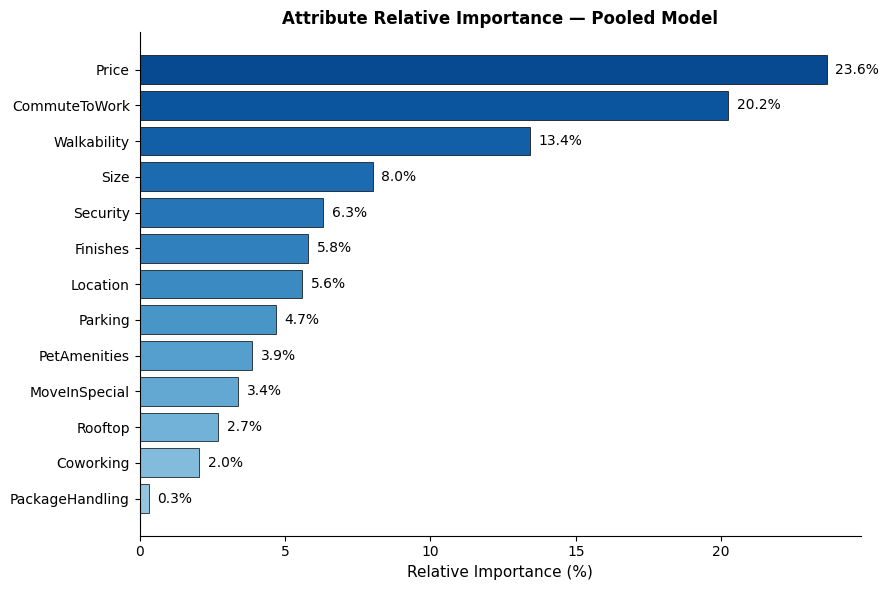

In [10]:
# Relative importance (per-attribute utility range)
importance = {}
for attr in attr_names:
    if attr in CONTINUOUS_ATTRS:
        values = [v for v in ATTRIBUTES[attr].values() if v is not None]
        beta = coef_df.loc[coef_df['feature'] == f"{attr}_num", 'coef'].values[0]
        importance[attr] = abs(beta) * (max(values) - min(values))
    else:
        coefs = [0.0]
        for c in dummy_cols:
            if c.startswith(f"{attr}__"):
                coefs.append(coef_df.loc[coef_df['feature'] == c, 'coef'].values[0])
        importance[attr] = max(coefs) - min(coefs)

imp_df = pd.DataFrame.from_dict(importance, orient='index', columns=['utility_range'])
imp_df['pct'] = 100 * imp_df['utility_range'] / imp_df['utility_range'].sum()
imp_df = imp_df.sort_values('pct', ascending=True)
imp_df.to_csv(DATA_DIR / 'relative_importance.csv')

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df)))
ax.barh(imp_df.index, imp_df['pct'], color=colors, edgecolor='black', linewidth=0.5)
for i, (attr, row) in enumerate(imp_df.iterrows()):
    ax.text(row['pct'] + 0.3, i, f"{row['pct']:.1f}%", va='center', fontsize=10)
ax.set_xlabel('Relative Importance (%)', fontsize=11)
ax.set_title('Attribute Relative Importance — Pooled Model', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'relative_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# In the WTP plot cell, before building labels:
ATTR_BASELINES = {attr: list(ATTRIBUTES[attr].keys())[0] for attr in CATEGORICAL_ATTRS}

wtp_cat['baseline'] = wtp_cat['attribute'].map(ATTR_BASELINES)
wtp_cat['label'] = (
    wtp_cat['attribute'] + ': ' +
    wtp_cat['level'].str.split(r' \(').str[0].str[:30] +
    ' (vs. ' +
    wtp_cat['baseline'].str.split(r' \(|: ').str[0].str[:25] +
    ')'
)

NameError: name 'wtp_cat' is not defined

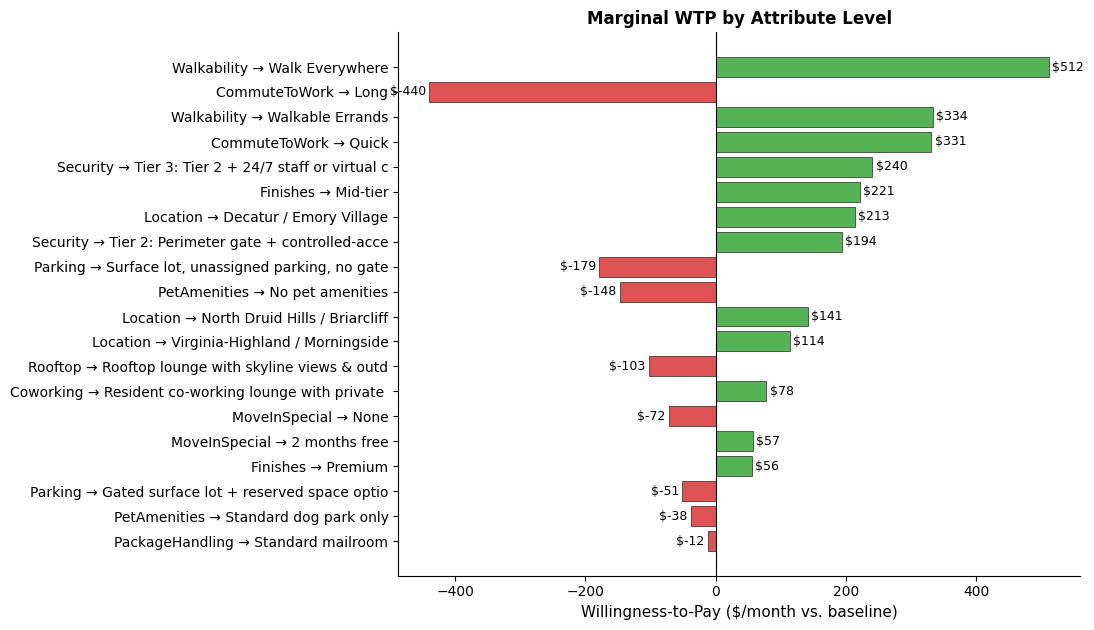

In [ ]:
# WTP dollars plot
wtp_cat = wtp_df[wtp_df['attribute'].isin(CATEGORICAL_ATTRS)].copy()
wtp_cat = wtp_cat.sort_values('WTP_$/mo', key=abs, ascending=True)
wtp_cat['label'] = wtp_cat['attribute'] + ' → ' + wtp_cat['level'].str.split(r' \(').str[0].str[:40]

fig, ax = plt.subplots(figsize=(11, max(6, 0.32 * len(wtp_cat))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in wtp_cat['WTP_$/mo']]
ax.barh(wtp_cat['label'], wtp_cat['WTP_$/mo'], color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
for i, (_, row) in enumerate(wtp_cat.iterrows()):
    offset = 5 if row['WTP_$/mo'] >= 0 else -5
    align = 'left' if row['WTP_$/mo'] >= 0 else 'right'
    ax.text(row['WTP_$/mo'] + offset, i, f"${row['WTP_$/mo']:.0f}", va='center', ha=align, fontsize=9)
ax.set_xlabel('Willingness-to-Pay ($/month vs. baseline)', fontsize=11)
ax.set_title('Marginal WTP by Attribute Level', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_DIR / 'wtp_dollars.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-Persona Models

Fit a separate MNL for each persona to recover segment-specific WTP and price elasticity. These feed into Notebook 3 for population-weighted market-share simulation.

In [12]:
persona_coefs = {}

for persona in long_df_encoded['Persona'].unique():
    sub = long_df_encoded[long_df_encoded['Persona'] == persona].copy()
    if len(sub) < 100:
        print(f"Skipping {persona}: too few observations")
        continue
    X_p = sub[feature_cols].values.astype(float)
    y_p = sub['choice'].values.astype(int)
    ids_p = sub['ObsID'].values
    alt_p = sub['Alt'].values
    print(f"\n=== {persona} (n_obs={sub['ObsID'].nunique()}) ===")
    try:
        m = MultinomialLogit()
        m.fit(X=X_p, y=y_p, varnames=feature_cols, ids=ids_p, alts=alt_p)
        persona_coefs[persona] = pd.DataFrame({
            'feature': feature_cols,
            'coef': m.coeff_,
            'p_value': m.pvalues,
        })
        bp = persona_coefs[persona].loc[persona_coefs[persona]['feature'] == 'Price_num', 'coef'].values[0]
        bs = persona_coefs[persona].loc[persona_coefs[persona]['feature'] == 'Size_num', 'coef'].values[0]
        if bp < 0:
            print(f"  β_price: {bp:.6f}  |  WTP per SF: ${-bs/bp:.2f}/mo")
        else:
            print(f"  ⚠ β_price = {bp:.6f} (non-negative — segment may need more obs)")
    except Exception as e:
        print(f"  Failed: {e}")

print(f"\nFit {len(persona_coefs)} per-persona models.")


=== emory_grad (n_obs=1800) ===
  β_price: -0.010994  |  WTP per SF: $0.40/mo

=== vahi_professional (n_obs=1800) ===
  β_price: -0.023288  |  WTP per SF: $0.29/mo

=== empty_nester (n_obs=1800) ===
  β_price: -0.007771  |  WTP per SF: $1.15/mo

=== skeptical_renter_control (n_obs=1800) ===
  β_price: -0.018941  |  WTP per SF: $0.36/mo

Fit 4 per-persona models.


In [13]:
# Save per-persona coefficients for Notebook 3
persona_coefs_serializable = {
    p: pdf.to_dict('records') for p, pdf in persona_coefs.items()
}
with open(DATA_DIR / 'persona_coefs.json', 'w') as f:
    json.dump(persona_coefs_serializable, f, indent=2)

# Same data as CSV (for hosts that block JSON upload)
persona_coefs_rows = []
for p, pdf in persona_coefs.items():
    for _, row in pdf.iterrows():
        persona_coefs_rows.append({
            'persona': p,
            'feature': row['feature'],
            'coef': row['coef'],
            'p_value': row['p_value'],
        })
pd.DataFrame(persona_coefs_rows).to_csv(DATA_DIR / 'persona_coefs.csv', index=False)

# Save pooled coefficients
coef_df.to_csv(DATA_DIR / 'pooled_coefs.csv', index=False)

# Save ATTRIBUTES dict
with open(DATA_DIR / 'attributes.json', 'w') as f:
    json.dump(ATTRIBUTES, f, indent=2)

# Flatten attributes for CSV (baseline = first row per attribute by level_order)
attr_rows = []
for attr, levels in ATTRIBUTES.items():
    for level_order, (level, val) in enumerate(levels.items(), start=1):
        attr_rows.append({
            'attribute': attr,
            'level': level,
            'numeric_value': '' if val is None else val,
            'level_order': level_order,
        })
pd.DataFrame(attr_rows).to_csv(DATA_DIR / 'attributes.csv', index=False)

print("Saved for Notebook 3:")
print(f"  - data/persona_coefs.json")
print(f"  - data/persona_coefs.csv")
print(f"  - data/pooled_coefs.csv")
print(f"  - data/attributes.json")
print(f"  - data/attributes.csv")

Saved for Notebook 3:
  - data/persona_coefs.json
  - data/persona_coefs.csv
  - data/pooled_coefs.csv
  - data/attributes.json
  - data/attributes.csv


## 8. Per-Persona WTP Heatmap

In [14]:
# Build comparison table of key WTPs across personas
key_features = [c for c in dummy_cols if any(
    k in c for k in ['Walkability__Walk Everywhere', 'Security__Tier 3', 'Finishes__Premium',
                     'Parking__Dedicated', 'Rooftop__Rooftop', 'Coworking__Resident',
                     'Location__Virginia-Highland', 'PackageHandling__24/7']
)]

rows = []
for persona, pdf in persona_coefs.items():
    bp = pdf.loc[pdf['feature'] == 'Price_num', 'coef'].values[0]
    if bp >= 0:
        continue
    for feat in key_features:
        match = pdf.loc[pdf['feature'] == feat, 'coef']
        b = match.values[0] if len(match) > 0 else np.nan
        rows.append({
            'persona': persona,
            'feature': feat.split('__', 1)[1][:45],
            'WTP_$/mo': -b / bp if not np.isnan(b) else np.nan,
        })

compare_df = pd.DataFrame(rows)
pivot = compare_df.pivot(index='feature', columns='persona', values='WTP_$/mo').round(0)
print("Per-Persona WTP ($/month vs. baseline):\n")
print(pivot.fillna('—'))
pivot.to_csv(DATA_DIR / 'persona_wtp.csv')

Per-Persona WTP ($/month vs. baseline):

persona                                        emory_grad  empty_nester  \
feature                                                                   
Premium (quartz waterfall island, smart therm         6.0         200.0   
Resident co-working lounge with private call        107.0          13.0   
Rooftop lounge with skyline views & outdoor s       -65.0          37.0   
Tier 3: Tier 2 + 24/7 staff or virtual concie       106.0         210.0   
Virginia-Highland / Morningside                      47.0         217.0   
Walk Everywhere (daily errands, dining, trans       317.0         852.0   

persona                                        skeptical_renter_control  \
feature                                                                   
Premium (quartz waterfall island, smart therm                      81.0   
Resident co-working lounge with private call                       40.0   
Rooftop lounge with skyline views & outdoor s             

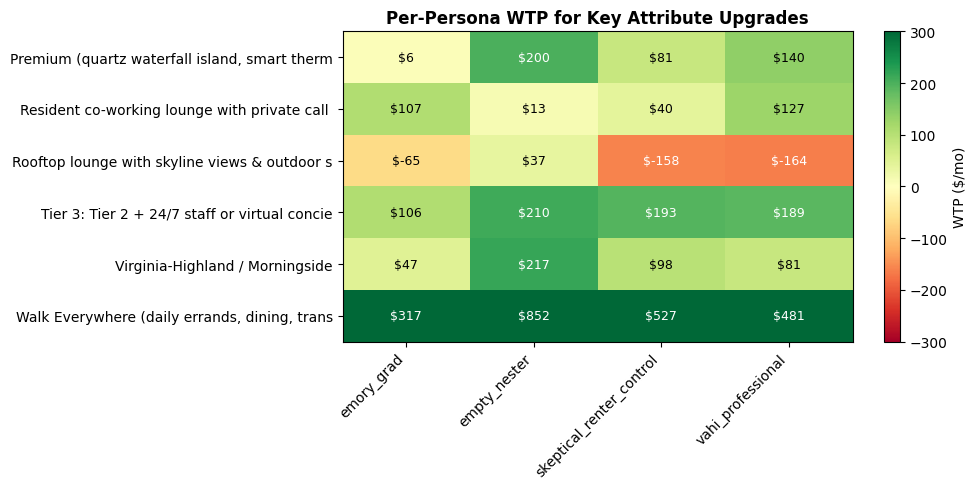

In [15]:
# Heatmap
fig, ax = plt.subplots(figsize=(10, max(5, 0.5 * len(pivot))))
data = pivot.values.astype(float)
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-300, vmax=300)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"${v:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > 150 else 'black')
plt.colorbar(im, ax=ax, label='WTP ($/mo)')
ax.set_title('Per-Persona WTP for Key Attribute Upgrades', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'persona_wtp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sanity Check: Top WTP Drivers

In [16]:
wtp_sorted = wtp_df.sort_values('WTP_$/mo', ascending=False)
print("=== TOP 5 POSITIVE WTP DRIVERS ===\n")
print(wtp_sorted.head(5)[['attribute', 'level', 'WTP_$/mo', 'p_value']].to_string(index=False))
print("\n=== TOP 5 NEGATIVE WTP DRIVERS ===\n")
print(wtp_sorted.tail(5)[['attribute', 'level', 'WTP_$/mo', 'p_value']].to_string(index=False))
print("\nAll outputs saved. Open Notebook 3 for interactive market-share simulation.")

=== TOP 5 POSITIVE WTP DRIVERS ===

    attribute                                                                                  level  WTP_$/mo  p_value
  Walkability Walk Everywhere (daily errands, dining, transit within a 10-min walk of this building)    511.72      0.0
  Walkability Walkable Errands (groceries & a few restaurants within a 10-min walk of this building)    333.51      0.0
CommuteToWork                                                            Quick (under 15 min by car)    331.02      0.0
     Security              Tier 3: Tier 2 + 24/7 staff or virtual concierge + smart locks throughout    240.46      0.0
     Finishes         Mid-tier (granite/quartz counters, stainless appliances, in-unit washer/dryer)    221.19      0.0

=== TOP 5 NEGATIVE WTP DRIVERS ===

    attribute                                               level  WTP_$/mo  p_value
MoveInSpecial                                                None    -72.00      0.0
      Rooftop Rooftop lounge with sky